<h3  style = "color: skyblue" >Importing Libraries<h3>

In [96]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, train_test_split

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


<h3  style = "color: skyblue" >Data Ingestion and Loading<h3>

In [97]:
df = pd.read_excel("../data/premiums_rest.xlsx")
print("Few observations:")
df.head()

Few observations:


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


<h3 style = "color:skyblue" >Data Overview</h3>

In [98]:
print("Number of rows and columns:", df.shape)
print("Number of duplicated observations:", df.duplicated().sum())
print("====" * 10)
print("Data Types of each fields:\n")
print(df.dtypes)
print("====" * 10)
print("Number of missing values per columns:")
df.isna().sum()

Number of rows and columns: (29904, 13)
Number of duplicated observations: 0
Data Types of each fields:

Age                       int64
Gender                   object
Region                   object
Marital_status           object
Number Of Dependants      int64
BMI_Category             object
Smoking_Status           object
Employment_Status        object
Income_Level             object
Income_Lakhs              int64
Medical History          object
Insurance_Plan           object
Annual_Premium_Amount     int64
dtype: object
Number of missing values per columns:


Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           9
Employment_Status        1
Income_Level             9
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

<h3 style = "color:skyblue" >Sanity Cleaning</h3>

In [99]:
#making field names consistent
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [100]:
#lower + snakecase
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [101]:
#since the number of missng value is small we can delete it
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

<h3 style = "color:skyblue" >Exploratory Data Analysis</h3>

#### 1. Summary Stats

In [102]:
print("Quick Summary Statistics:")
df.describe()

Quick Summary Statistics:


,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.379910,23.364184,20892.303821
std,13.412657,1.431201,24.740339,6936.813440
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


Problems -
* certainly an outliers in the `age` field.
* number of dependants cannot be `negative`
* maybe an outlier in income_lakhs

In [103]:
# solve for the number of dependants
df['number_of_dependants'].unique()

array([ 0,  2,  3,  4,  1,  5, -1, -3], dtype=int64)

In [104]:
# there are 72 observations that is less that has negative values
# there may be some error in data entry and maybe it is +ve values
# talked to business and they said to replace with +ve values 
df[df['number_of_dependants'] < 0].shape

(50, 13)

In [105]:
df['number_of_dependants'] = df['number_of_dependants'].abs()
df['number_of_dependants'].unique()

array([0, 2, 3, 4, 1, 5], dtype=int64)

#### 2. Univariate Analysis - numeric 

In [106]:
numeric_columns = df.select_dtypes('number').columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

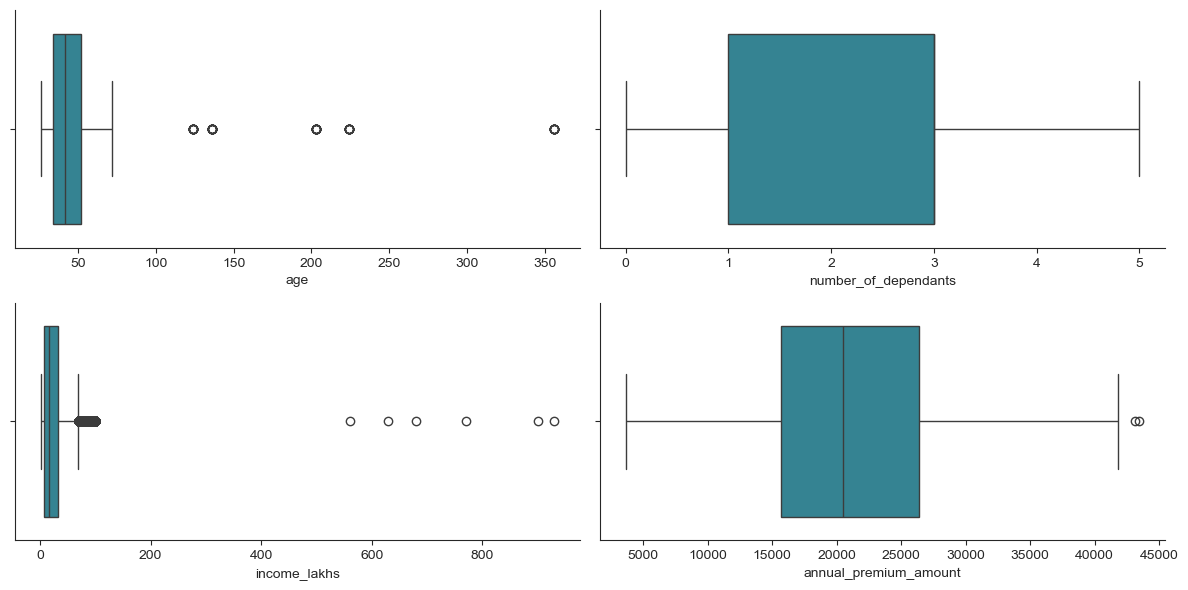

In [107]:
#solve for outliers
#numeric
plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.boxplot(x=df[col], color="#258DA2")
    
    
plt.tight_layout()
sns.despine()
plt.show()

In [108]:
# Outlier Treatment for age column 
# We do not need Statistical techniques for removing the outlier in age
# Simply use a threshold value

df[df['age'] > 100].head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
77,224,Male,Northeast,Married,3,Normal,Regular,Salaried,25L - 40L,26,No Disease,Gold,27523
488,124,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,46,No Disease,Silver,11752
803,124,Female,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,3,No Disease,Bronze,5311
902,124,Female,Southwest,Unmarried,1,Overweight,No Smoking,Salaried,<10L,2,Diabetes,Bronze,10238
912,136,Male,Southeast,Married,3,Overweight,Regular,Self-Employed,10L - 25L,15,High blood pressure,Gold,31913


In [109]:
df[df['age'] > 100]['age'].unique()

array([224, 124, 136, 203, 356], dtype=int64)

In [110]:
#do reverse condition for filtering the age
#create a copy
data = df[df['age'] <= 100].copy()
data['age'].describe()

count    29828.000000
mean        43.095380
std         11.041991
min         26.000000
25%         34.000000
50%         42.000000
75%         52.000000
max         72.000000
Name: age, dtype: float64

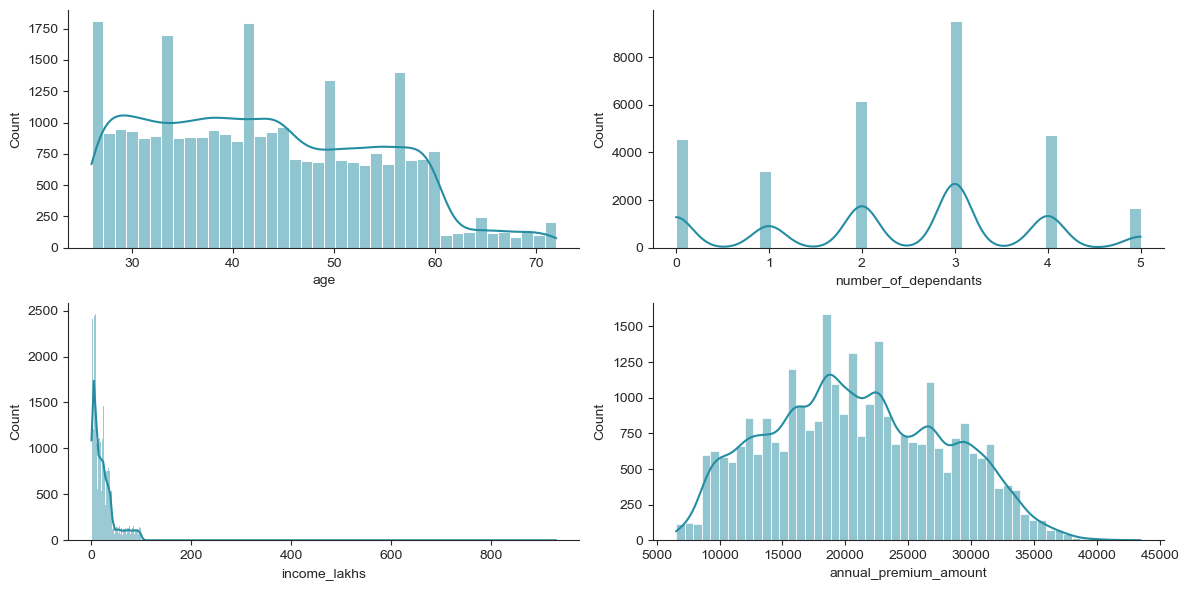

In [111]:
#distribution plot with outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()



In [112]:
# Outlier Treatment for income_lakhs column
# Using an IQR method to solve outlier problem

data['income_lakhs'].describe()


count    29828.000000
mean        23.371530
std         24.751262
min          1.000000
25%          7.000000
50%         17.000000
75%         32.000000
max        930.000000
Name: income_lakhs, dtype: float64

In [113]:
#quantile
Q1, Q3 = data['income_lakhs'].quantile([0.25, 0.75])
Q1, Q3

(7.0, 32.0)

In [114]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound


In [115]:
get_iqr_bounds(data['income_lakhs'])

(-30.5, 69.5)

- 67 LPA is okay but can I use it as my upperbound
- Try bunch of other methods

In [116]:
data['income_lakhs'].quantile(0.999)

100.0

In [117]:
qunatile_threshhold = data['income_lakhs'].quantile(0.999)
qunatile_threshhold

100.0

1 Cr income is okay when we use upper bound as 0.999

In [118]:
print("Observations that has income more than threshold i.e 1 Cr: ")
data[data['income_lakhs'] > qunatile_threshhold]


Observations that has income more than threshold i.e 1 Cr: 


,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
1598,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692
4657,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010
5399,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848
6149,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945
21176,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115
24489,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926


In [119]:
print(f"Number of such observations: {data[data['income_lakhs'] > qunatile_threshhold].shape}")

Number of such observations: (6, 13)


In [120]:
# drop those columns that has income > 1 Cr
# do reverse condition
data = data[data['income_lakhs'] <= qunatile_threshhold]
data["income_lakhs"].describe()

count    29822.000000
mean        23.226343
std         22.455408
min          1.000000
25%          7.000000
50%         17.000000
75%         32.000000
max        100.000000
Name: income_lakhs, dtype: float64

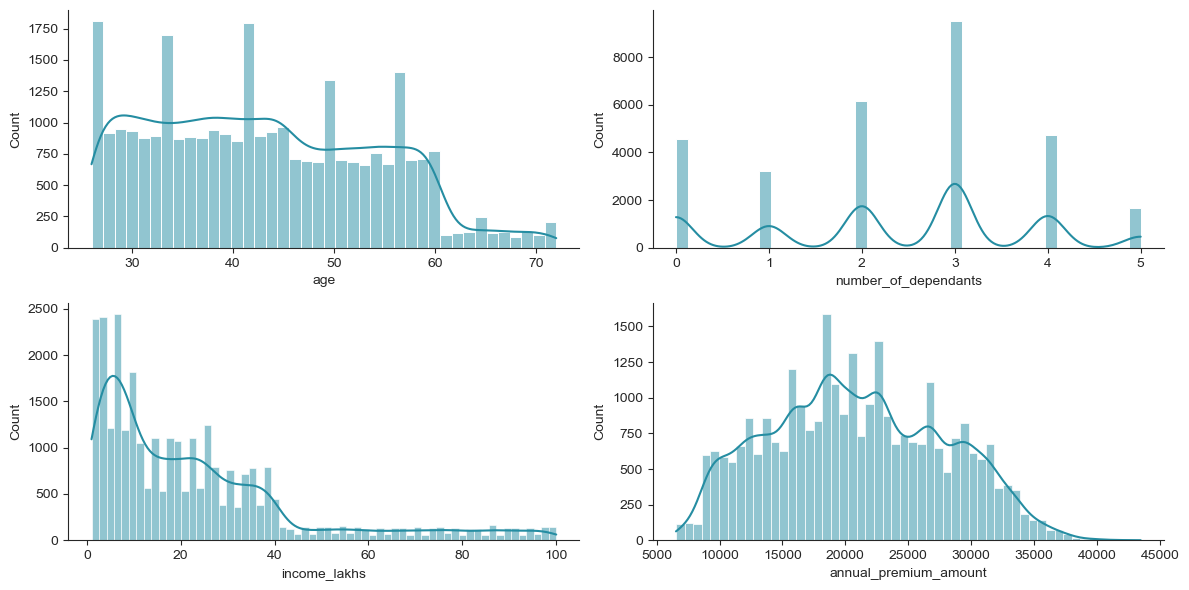

In [121]:
#distribution plot after removal of outliers

plt.figure(figsize=(12, 6))

ncols = 2
nrows = math.ceil(len(numeric_columns) / ncols)

for i, col in enumerate(numeric_columns, start=1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(x=data[col], color="#258DA2", kde= True)
    
    
plt.tight_layout()
sns.despine()
plt.show()

#### 2. Bivariate Analysis - numeric


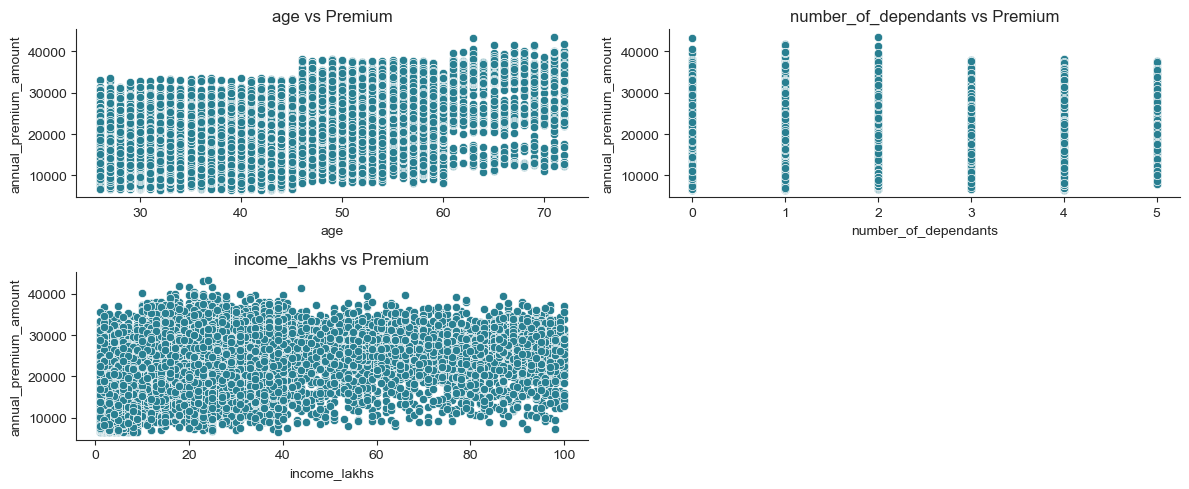

In [122]:

# Scatter plots: numeric vs target
scatter_cols = numeric_columns.drop('annual_premium_amount')

plt.figure(figsize=(12, 5))

ncols = 2
nrows = math.ceil(len(scatter_cols) / ncols)

for i, col in enumerate(scatter_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.scatterplot(data=data, x=col, y='annual_premium_amount', color="#297F91")
    plt.title(f"{col} vs Premium")

plt.tight_layout()
sns.despine()
plt.show()


#### Categorical Columns

In [123]:
categorical_cols = data.select_dtypes('object').columns
categorical_cols

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [124]:
for col in categorical_cols:
    print(col, ":", data[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


There is clearly some data inconsistency in smoking status


In [125]:
#make value consistent
data['smoking_status'] = data['smoking_status'].replace({
    'Smoking=0' : 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking'
})

data['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

#### Summary Stats

In [126]:
data.select_dtypes('object').describe().T

,count,unique,top,freq
gender,29822,2,Male,16376
region,29822,4,Southeast,10518
marital_status,29822,2,Married,22267
bmi_category,29822,4,Normal,11870
smoking_status,29822,3,No Smoking,13483
employment_status,29822,3,Salaried,13901
income_level,29822,4,<10L,10922
medical_history,29822,9,Diabetes,8644
insurance_plan,29822,3,Silver,12455


####  Univariate Analysis - categorical

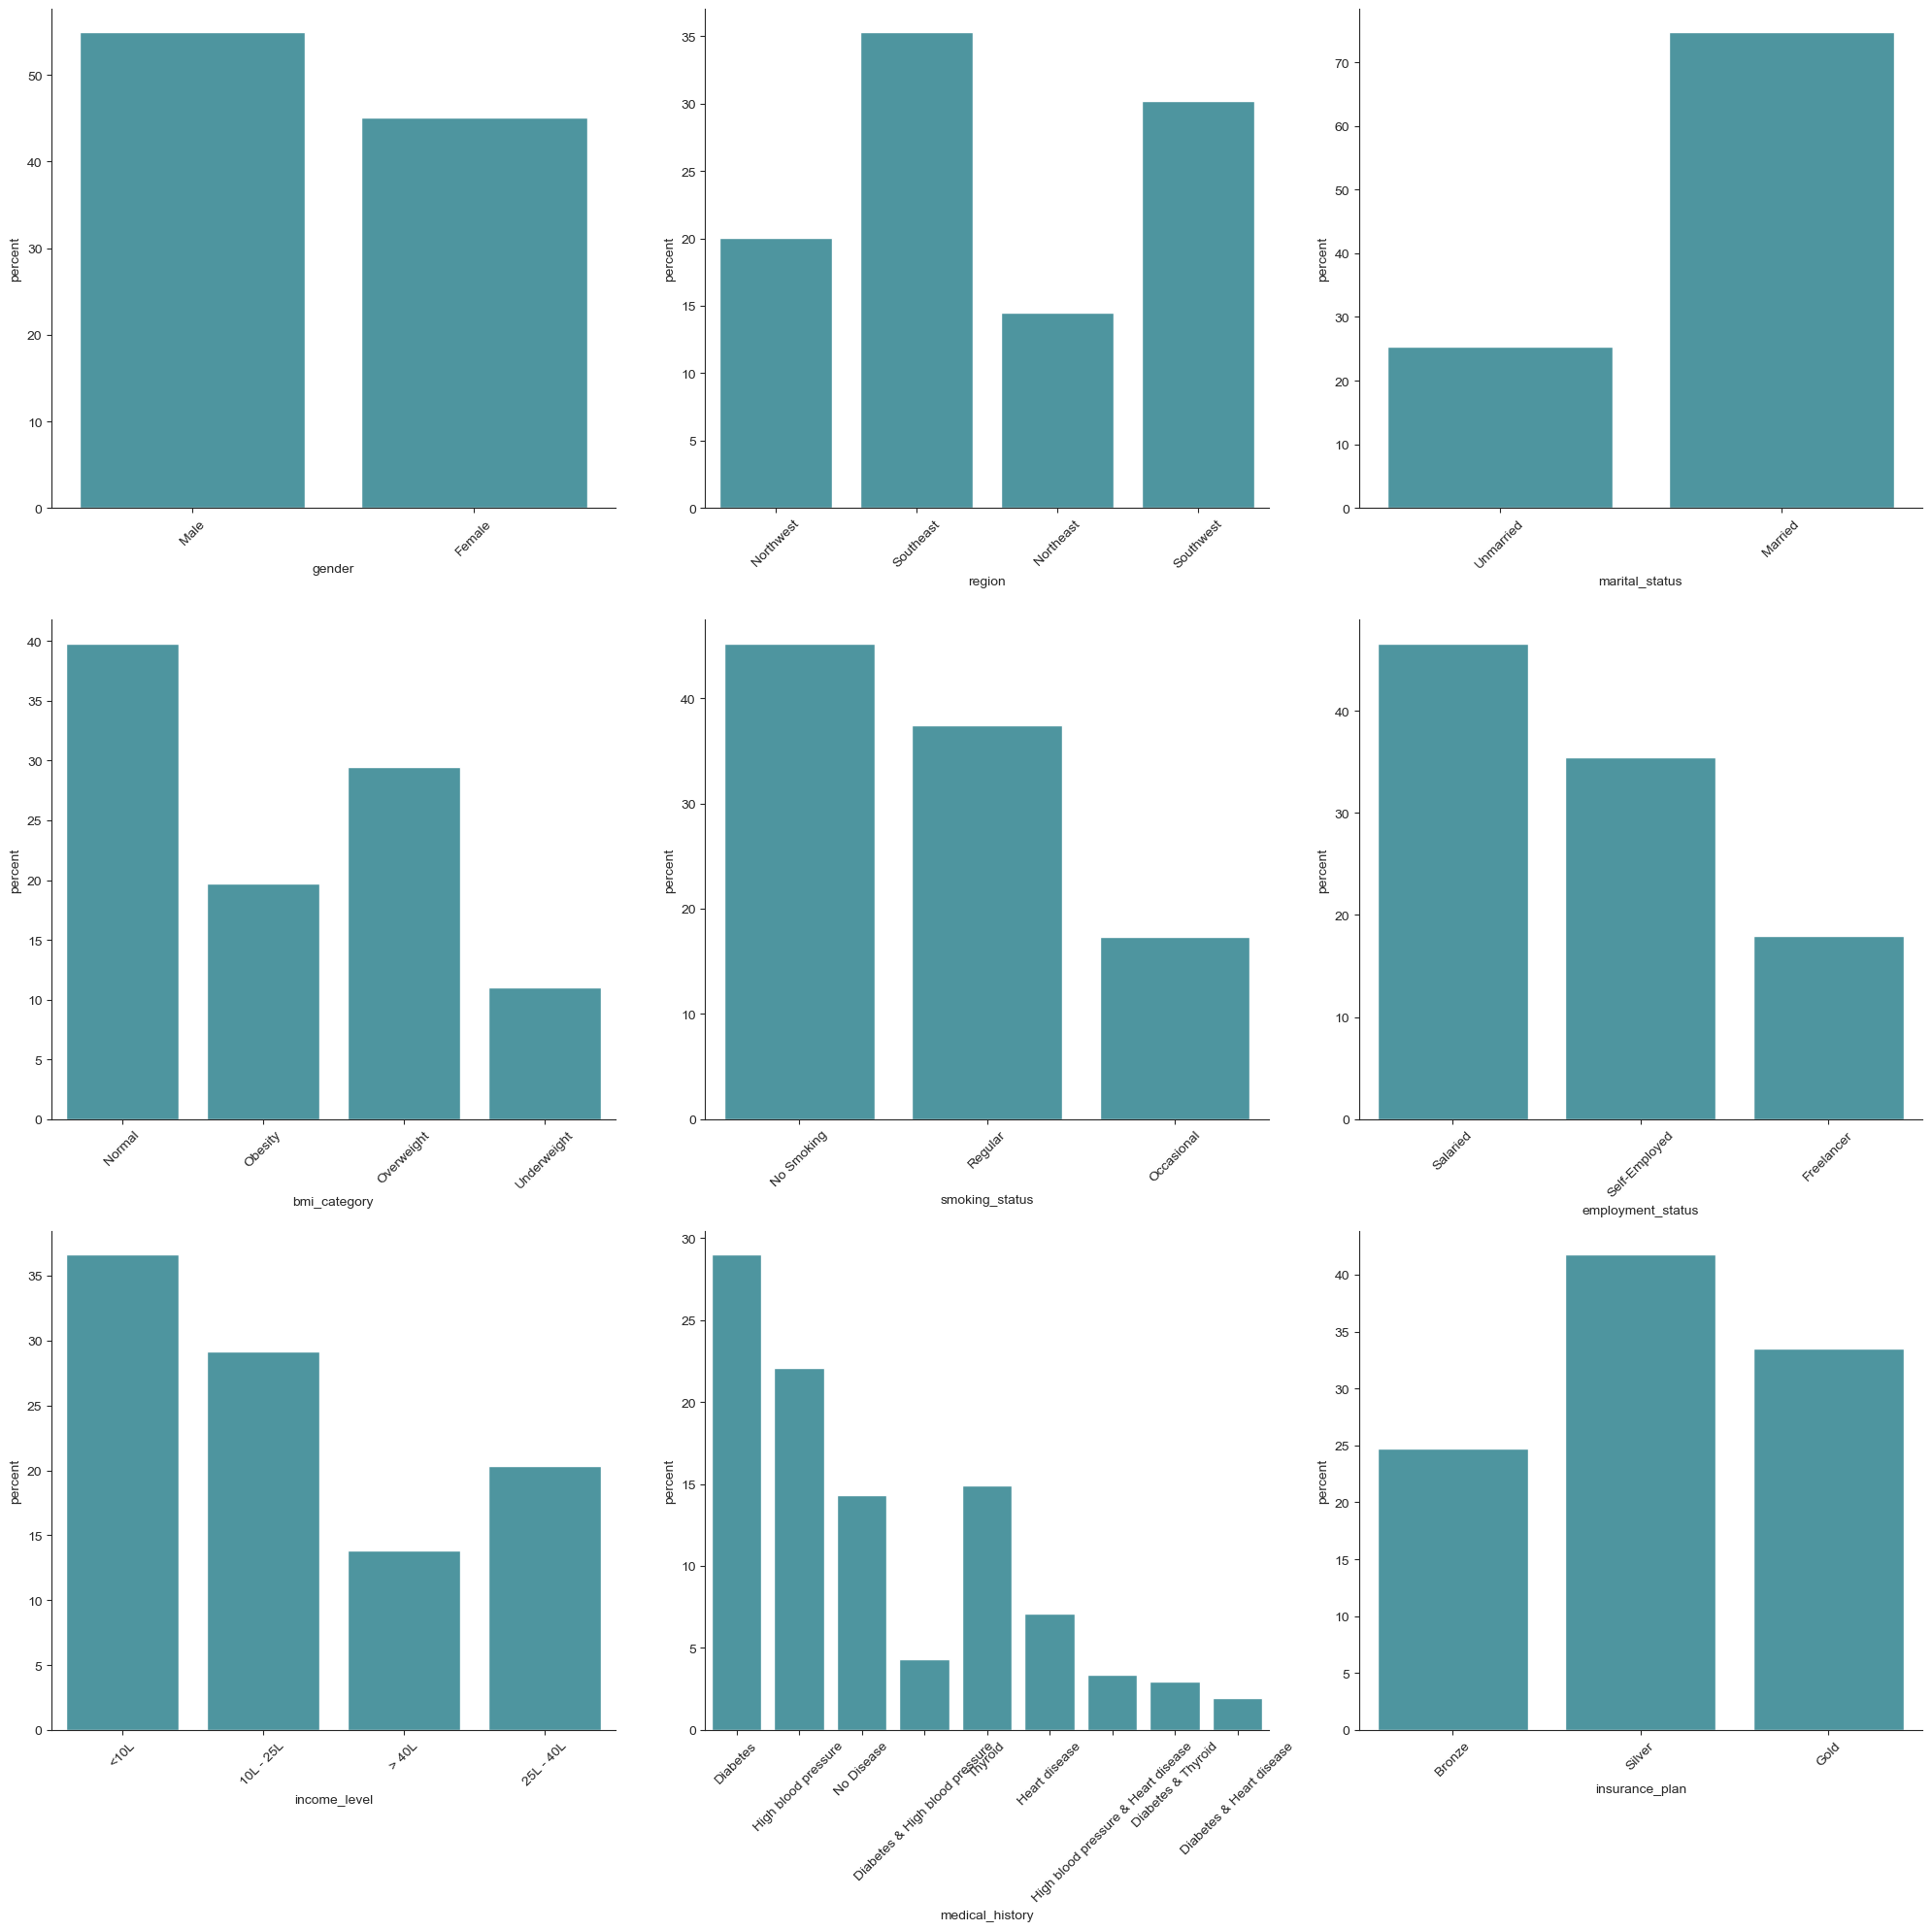

In [127]:
plt.figure(figsize=(20, 20))

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)

for i, col in enumerate(categorical_cols, start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent')
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


#### Bivariate Analysis - categorical


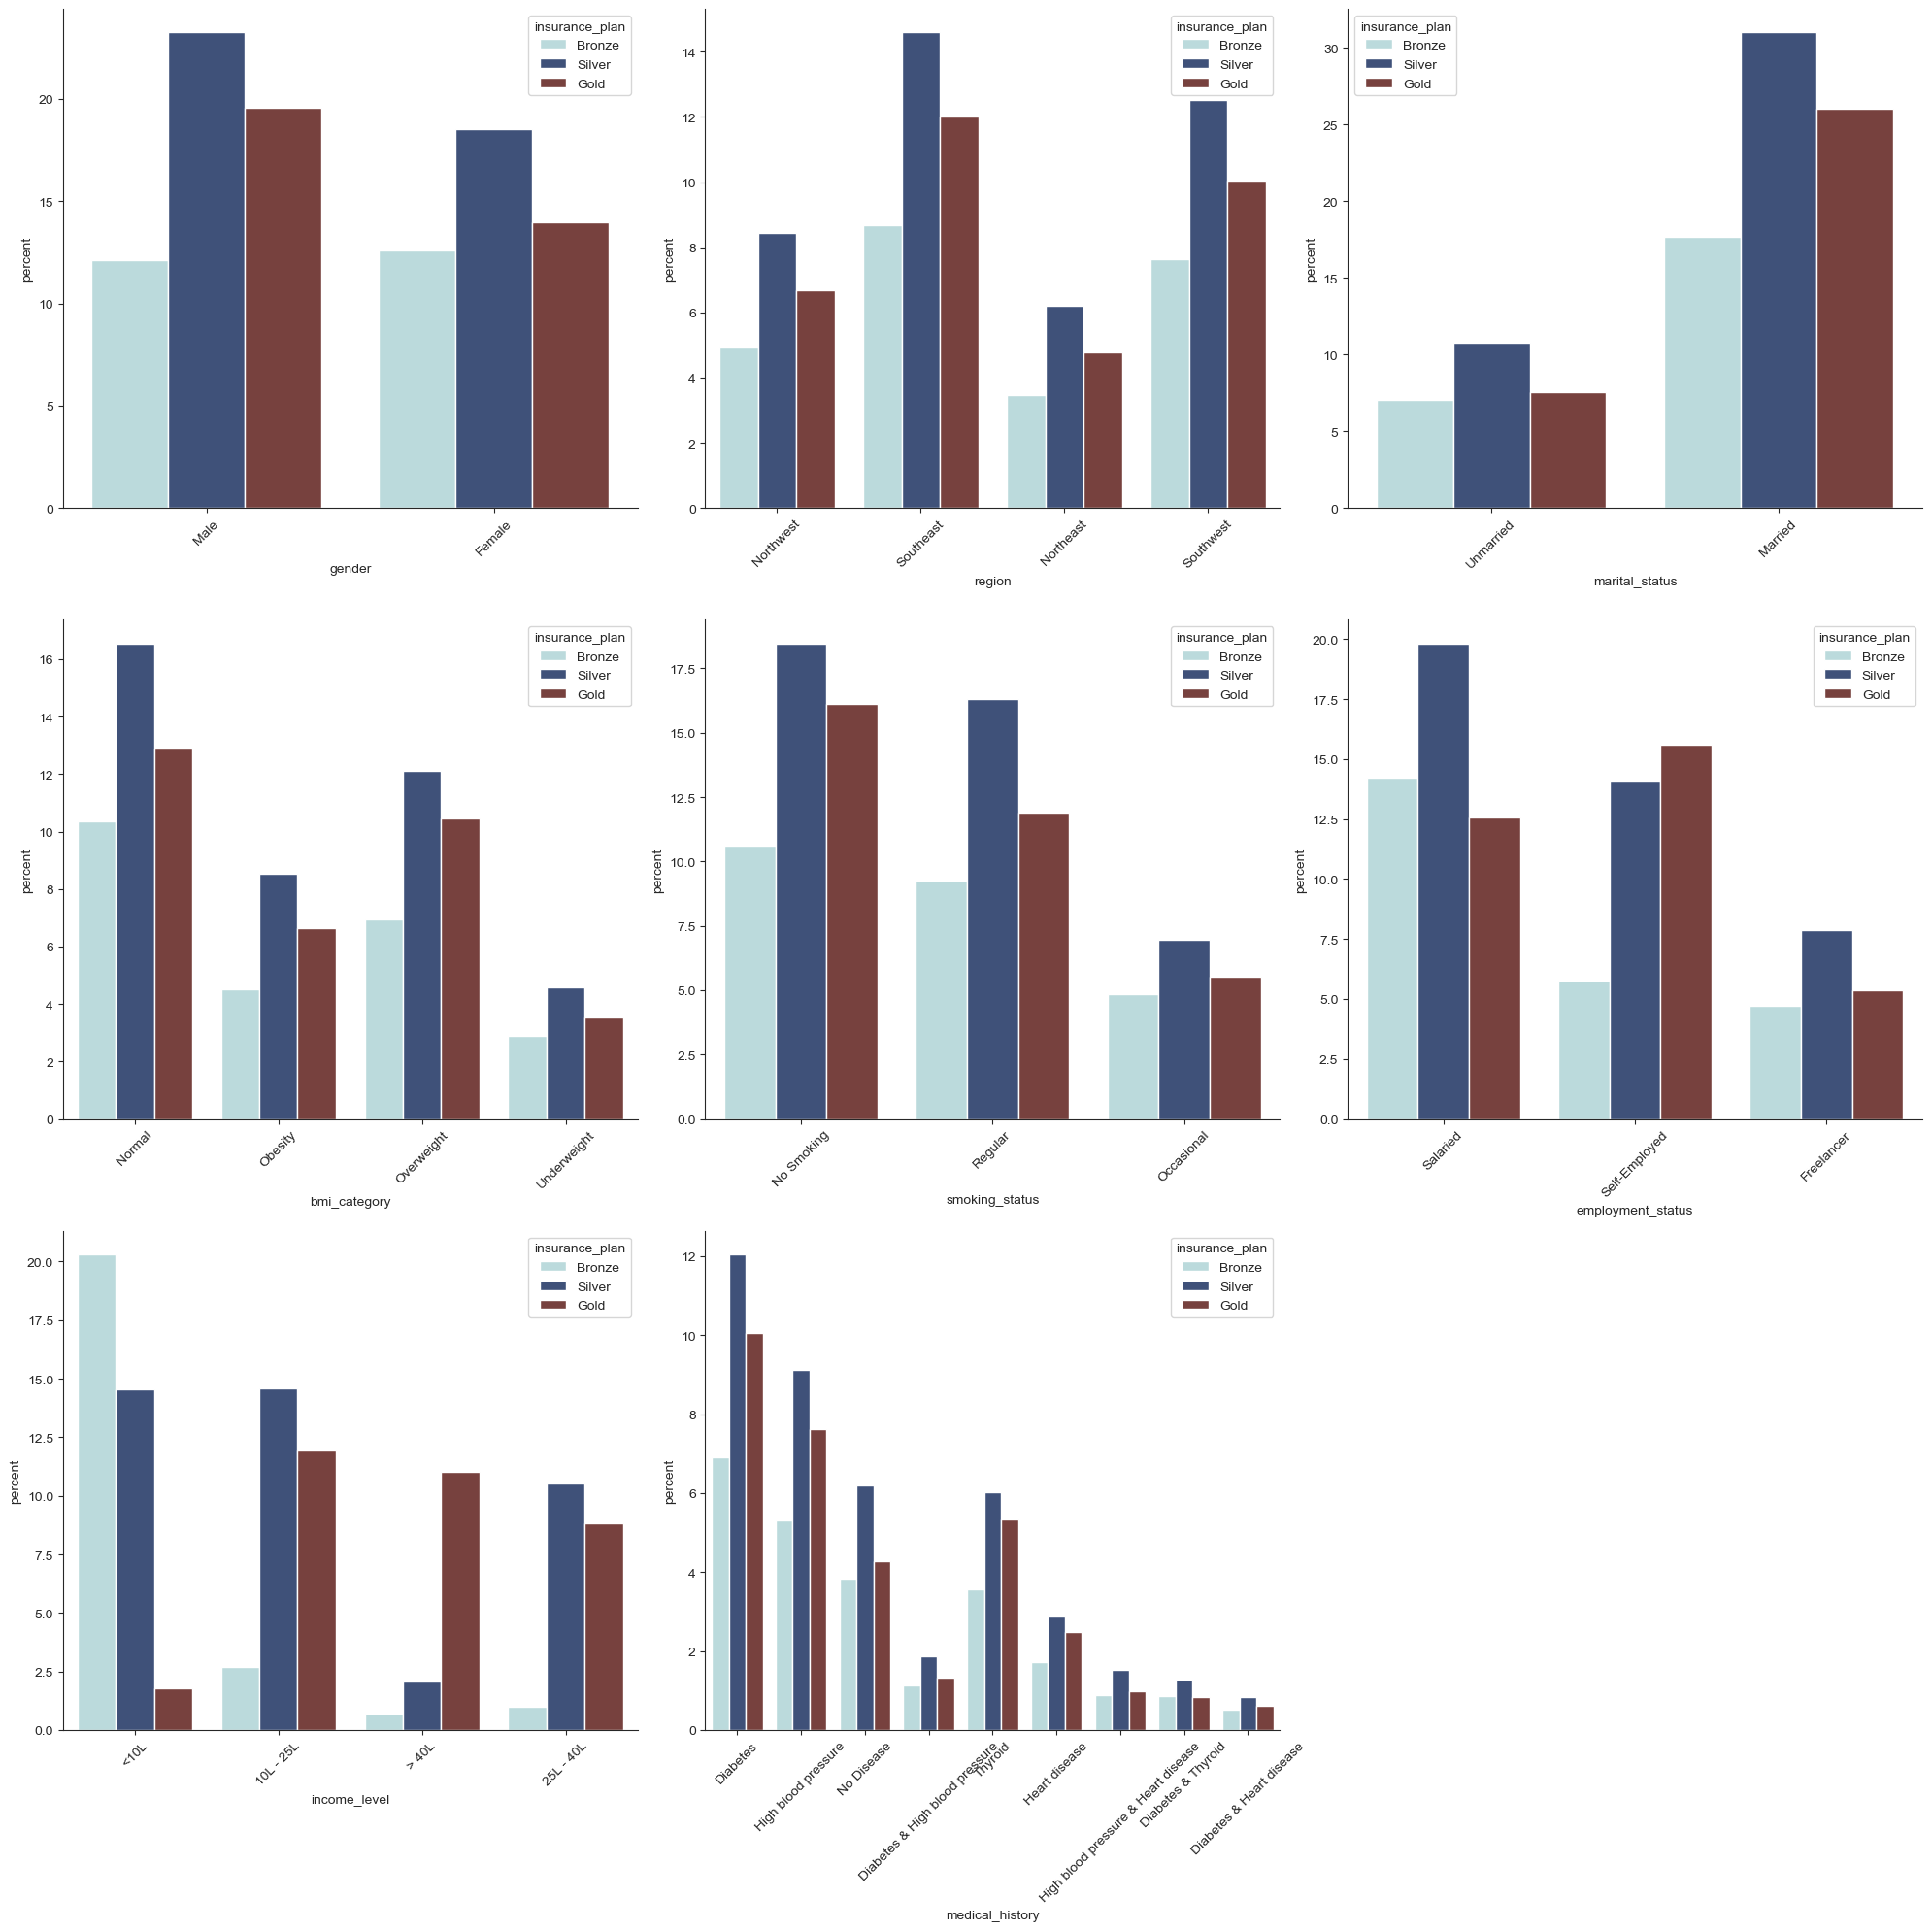

In [128]:
plt.figure(figsize=(20, 20))
sns.set_style('ticks')

ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)
Palette = ["#B5DFE2", "#354E83", "#803835"]

for i, col in enumerate(categorical_cols.drop('insurance_plan'), start=1):
    plt.subplot(nrows, ncols, i)
    sns.countplot(data=data, x=col, color="#409FAD", stat='percent', hue= data['insurance_plan'], palette= Palette)
    plt.xticks(rotation=45)

plt.tight_layout()
sns.despine()
plt.show()


<h3  style = "color: skyblue">Feature Engineering</h3>

1. Feature Construction
2. Feature Transformation
3. Feature Selection

#### 1. Feature Construction

In [129]:
data.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [130]:
data['medical_history'].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [131]:
# Define the risk scores for each condition

risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}


In [132]:
#sep each diseases, make dataframe, and make each case lower
data[['disease1', 'disease2']] = data['medical_history'].str.split("&", expand= True).apply( lambda x:x.str.lower().str.strip())

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
1929,46,Female,Northwest,Married,3,Obesity,No Smoking,Salaried,<10L,6,High blood pressure,Bronze,14795,high blood pressure,None
21051,54,Male,Northwest,Married,2,Obesity,Regular,Salaried,> 40L,40,Diabetes,Gold,33259,diabetes,None
23932,48,Female,Southeast,Married,4,Overweight,Occasional,Salaried,<10L,7,Diabetes,Bronze,13758,diabetes,None
17676,35,Male,Southeast,Married,4,Normal,Regular,Self-Employed,<10L,4,High blood pressure,Bronze,12363,high blood pressure,None
23654,33,Male,Northwest,Unmarried,0,Obesity,Regular,Salaried,25L - 40L,26,No Disease,Silver,20734,no disease,None


In [133]:
data['disease1'] = data['disease1'].fillna('none')
data['disease2'] = data['disease1'].fillna('none')

data['total_risk_scores'] = 0

In [134]:
data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores
26777,37,Male,Southeast,Married,3,Normal,Regular,Freelancer,25L - 40L,30,High blood pressure,Gold,25191,high blood pressure,high blood pressure,0
17352,56,Male,Southeast,Unmarried,0,Overweight,Regular,Freelancer,10L - 25L,17,High blood pressure & Heart disease,Gold,35179,high blood pressure,high blood pressure,0
26892,26,Female,Northwest,Married,2,Obesity,No Smoking,Salaried,10L - 25L,14,High blood pressure & Heart disease,Silver,23513,high blood pressure,high blood pressure,0
7503,41,Female,Southwest,Married,5,Overweight,Occasional,Salaried,10L - 25L,17,High blood pressure & Heart disease,Silver,22166,high blood pressure,high blood pressure,0
19192,27,Female,Southwest,Married,2,Underweight,No Smoking,Salaried,<10L,9,Thyroid,Bronze,9644,thyroid,thyroid,0


In [135]:
for disease in ['disease1', 'disease2']:
    data['total_risk_scores'] += data[disease].map(risk_scores)

data.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores
21199,50,Female,Southwest,Married,4,Obesity,No Smoking,Self-Employed,10L - 25L,10,Thyroid,Gold,30234,thyroid,thyroid,10
15513,43,Male,Northeast,Married,3,Overweight,No Smoking,Salaried,10L - 25L,22,Diabetes & Thyroid,Silver,19967,diabetes,diabetes,12
19326,35,Female,Northwest,Married,3,Underweight,No Smoking,Salaried,<10L,8,High blood pressure & Heart disease,Bronze,13422,high blood pressure,high blood pressure,12
27618,48,Male,Southeast,Married,3,Overweight,Occasional,Self-Employed,25L - 40L,29,High blood pressure,Gold,29581,high blood pressure,high blood pressure,12
29703,36,Female,Northeast,Married,3,Overweight,No Smoking,Salaried,<10L,3,Thyroid,Bronze,11412,thyroid,thyroid,10


#### 2. Feature Transformation

1. Label Encoding : `Ordinal Data`
2. One Hot Encoding: `Nominal Data`
3. Feature Scaling

Label Encoding for Ordinal Data

In [136]:
#For insurnace plan
#can do label encoding since it is ordinal data
data['insurance_plan'] = data['insurance_plan'].map({
    'Bronze': 1,
    'Silver': 2,
    'Gold': 3
})

data['insurance_plan'].unique()

array([1, 2, 3], dtype=int64)

In [137]:
#similarly for income_level we can do Label encoding
data['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [138]:
data['income_level'] = data['income_level'].map({
    '<10L': 1,
    '10L - 25L': 2,
    '25L - 40L': 3,
    '> 40L': 4
})

data['income_level'].unique()

array([1, 2, 4, 3], dtype=int64)

One Hot Encoding for Nominal Data

In [139]:
data.select_dtypes('object').columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'medical_history', 'disease1', 'disease2'],
      dtype='object')

In [140]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']

data_v1 = pd.get_dummies(data=data, columns= nominal_cols, drop_first= True, dtype='int')
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,diabetes,12,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,diabetes,12,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,high blood pressure,12,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,no disease,0,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,diabetes,diabetes,12,...,0,0,0,1,0,0,1,0,0,1


Feature Scaling

In [141]:
#Use MinMaxScaler
cols_to_scale = ['age', 'number_of_dependants', 'income_level',	'income_lakhs',	'insurance_plan', 'total_risk_scores']

scaler = MinMaxScaler()
data_v1[cols_to_scale] = scaler.fit_transform(data_v1[cols_to_scale])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_scores,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,Diabetes,0.0,9053,diabetes,diabetes,0.75,...,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,Diabetes,0.0,16339,diabetes,diabetes,0.75,...,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,High blood pressure,0.5,18164,high blood pressure,high blood pressure,0.75,...,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,No Disease,1.0,20303,no disease,no disease,0.00,...,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,Diabetes,0.0,15610,diabetes,diabetes,0.75,...,0,0,0,1,0,0,1,0,0,1


#### 3. Feature Selection

1. Business understanding

2. Statistical Techniques:
      - Filtered-based : correlation matrix
      - Embedded method

In [142]:
data_v1.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'disease1', 'disease2', 'total_risk_scores', 'gender_Male',
       'region_Northwest', 'region_Southeast', 'region_Southwest',
       'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [143]:
#Dropping some columns that is not necessary
data_v1 = data_v1.drop(columns=['medical_history', 'disease1', 'disease2'])
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,0.0,9053,0.75,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,0.0,16339,0.75,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,0.5,18164,0.75,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,1.0,20303,0.00,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,0.0,15610,0.75,1,0,0,0,0,1,0,0,1,0,0,1


#### 1. Filtered-based method

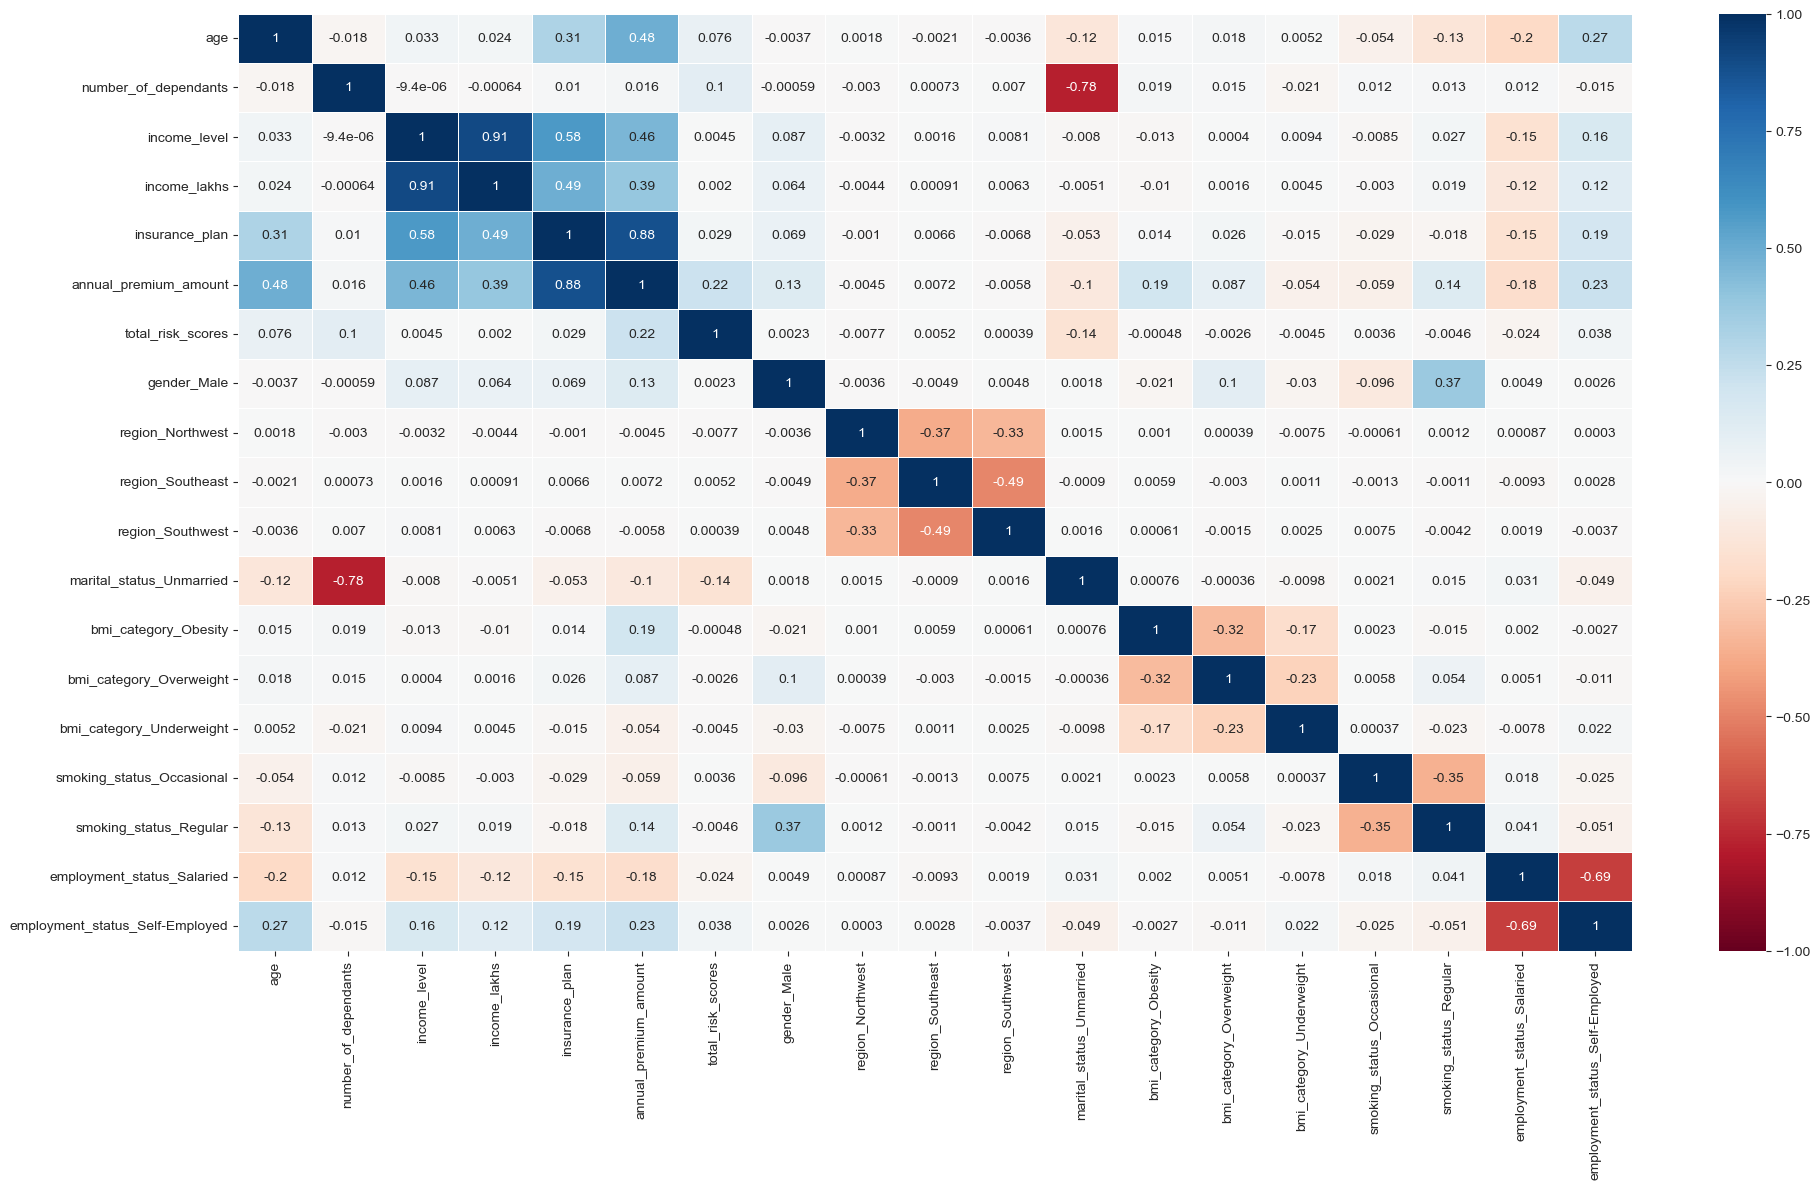

In [144]:
#Correlation matrix
cm = data_v1.corr()

plt.figure(figsize=(20,12))
sns.set_style('ticks')

sns.heatmap(cm, annot= True, vmin= -1, vmax=1, cmap="RdBu", linewidths=0.7)
plt.tight_layout()
plt.show()

Strong multicollinearity: (income_level, income_lakhs) and (insurance_plan, annual_premium_amount) are highly correlated.

Marital status effects: Unmarried is strongly negatively related to age, dependants, and premium.

##### Calculate VIF for Multicolinearity

In [145]:
data_v1.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,0.0,9053,0.75,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,0.0,16339,0.75,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,0.5,18164,0.75,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,1.0,20303,0.00,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,0.0,15610,0.75,1,0,0,0,0,1,0,0,1,0,0,1


In [146]:
X = data_v1.drop(columns=['annual_premium_amount'])
y = data_v1['annual_premium_amount']

In [147]:
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,total_risk_scores,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,0.0,0.75,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,0.0,0.75,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,0.5,0.75,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,1.0,0.00,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,0.0,0.75,1,0,0,0,0,1,0,0,1,0,0,1


In [148]:
y[:5]

0     9053
1    16339
2    18164
3    20303
4    15610
Name: annual_premium_amount, dtype: int64

In [149]:
def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df['Columns'] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])] 

    return vif_df

In [150]:
calculate_vif(X)

,Columns,VIF
0,age,4.015577
1,number_of_dependants,6.466447
2,income_level,13.883692
3,income_lakhs,11.185745
4,insurance_plan,5.275312
5,total_risk_scores,5.665904
6,gender_Male,2.601907
7,region_Northwest,2.136767
8,region_Southeast,3.004112
9,region_Southwest,2.726754


In [151]:
#we will drop income_lakhs due to high VIF value
X = X.drop(columns=['income_level'])

In [152]:
#recalculating VIF

calculate_vif(X)

,Columns,VIF
0,age,3.957399
1,number_of_dependants,6.465173
2,income_lakhs,2.678187
3,insurance_plan,4.578015
4,total_risk_scores,5.665307
5,gender_Male,2.594180
6,region_Northwest,2.135973
7,region_Southeast,3.002990
8,region_Southwest,2.725090
9,marital_status_Unmarried,2.383956


In [153]:
X.shape

(29822, 17)

<h3  style = "color: skyblue" >Modeling<h3>


Hold-out approach

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train:", X_train.shape)
print("y train:", y_train.shape)
print("y train:", X_test.shape)
print("y test:", y_test.shape)

x train: (20875, 17)
y train: (20875,)
y train: (8947, 17)
y test: (8947,)


Base Model: Linear Regression

In [155]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [156]:
y_pred = model_lr.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 2808348.5362844234
RMSE: 1675.8127986993127
R2 Score: 0.9406460625655855


Cross validation appraoch

In [157]:
kfold = KFold(n_splits=5, shuffle= True, random_state=42)

scores = cross_val_score(estimator = model_lr, X= X, y= y, cv=kfold, scoring='r2')

print("R2 scores for each folds:", scores)
print("Mean R2 score across all folds:", np.mean(scores))

R2 scores for each folds: [0.94205282 0.94000659 0.94086753 0.94135515 0.9409838 ]
Mean R2 score across all folds: 0.9410531763361369


In [158]:
model_lr.intercept_

5824.7915996965585

In [159]:
model_lr.coef_

array([ 6.66118903e+03, -1.31629039e+03, -6.33054675e+02,  1.47940702e+04,
        4.45093016e+03,  3.18158975e+01, -5.72313799e+01, -1.84239633e+01,
       -2.41412926e+00, -7.85402501e+02,  3.90198516e+03,  1.95881136e+03,
        6.53704647e+02,  8.41125438e+02,  2.80142238e+03, -5.76445843e+01,
        2.36929514e+02])

In [160]:
feature_importance = model_lr.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
number_of_dependants,-1316.290388
marital_status_Unmarried,-785.402501
income_lakhs,-633.054675
employment_status_Salaried,-57.644584
region_Northwest,-57.231380
region_Southeast,-18.423963
region_Southwest,-2.414129
gender_Male,31.815897
employment_status_Self-Employed,236.929514
bmi_category_Underweight,653.704647


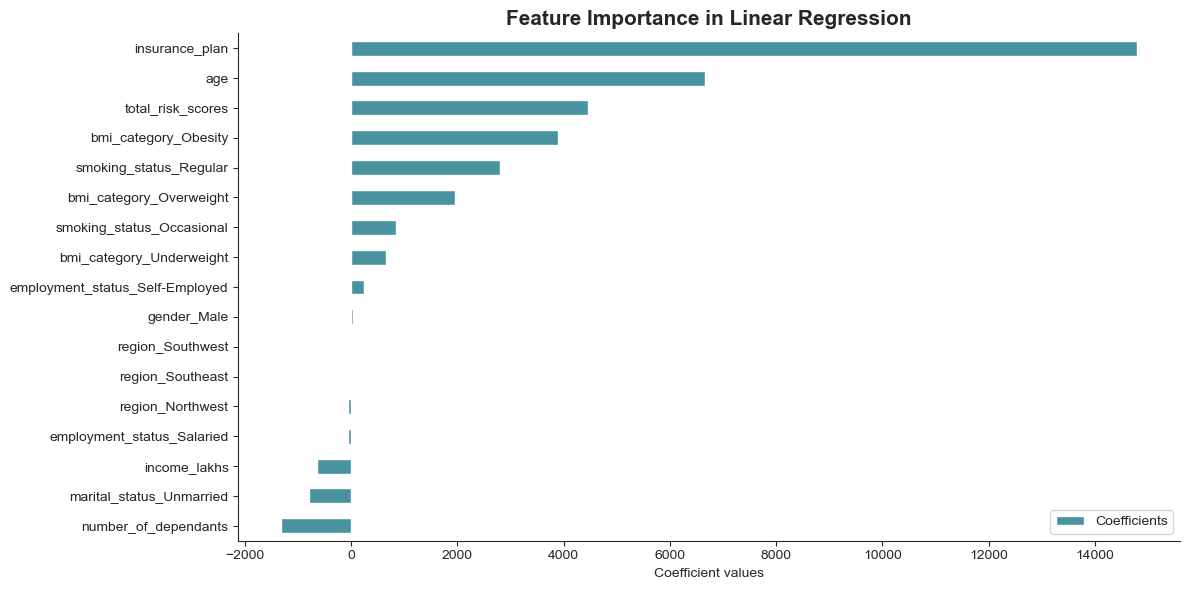

In [161]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Linear Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

Ridge Regression Model

In [162]:
model_rg = Ridge()
model_rg.fit(X_train, y_train)

Ridge()

In [163]:
y_pred = model_rg.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 2808409.8868921082
RMSE: 1675.8311033311527
R2 Score: 0.940644765931609


Lasso Regression Model

In [164]:
model_la = Lasso()
model_la.fit(X_train, y_train)

Lasso()

In [165]:
y_pred = model_la.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 2809303.833971241
RMSE: 1676.097799643935
R2 Score: 0.9406258725220771


In [166]:
model_la.intercept_

5809.897655986384

In [167]:
model_la.coef_

array([ 6.65713206e+03, -1.26908276e+03, -6.00983655e+02,  1.47806349e+04,
        4.44016946e+03,  2.99351593e+01, -4.57232628e+01, -8.82864365e+00,
        4.36685396e-01, -7.57977370e+02,  3.88926216e+03,  1.94862799e+03,
        6.37998351e+02,  8.29115787e+02,  2.79308942e+03, -5.50717056e+01,
        2.36192065e+02])

In [168]:
feature_importance = model_la.coef_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
number_of_dependants,-1269.082761
marital_status_Unmarried,-757.977370
income_lakhs,-600.983655
employment_status_Salaried,-55.071706
region_Northwest,-45.723263
region_Southeast,-8.828644
region_Southwest,0.436685
gender_Male,29.935159
employment_status_Self-Employed,236.192065
bmi_category_Underweight,637.998351


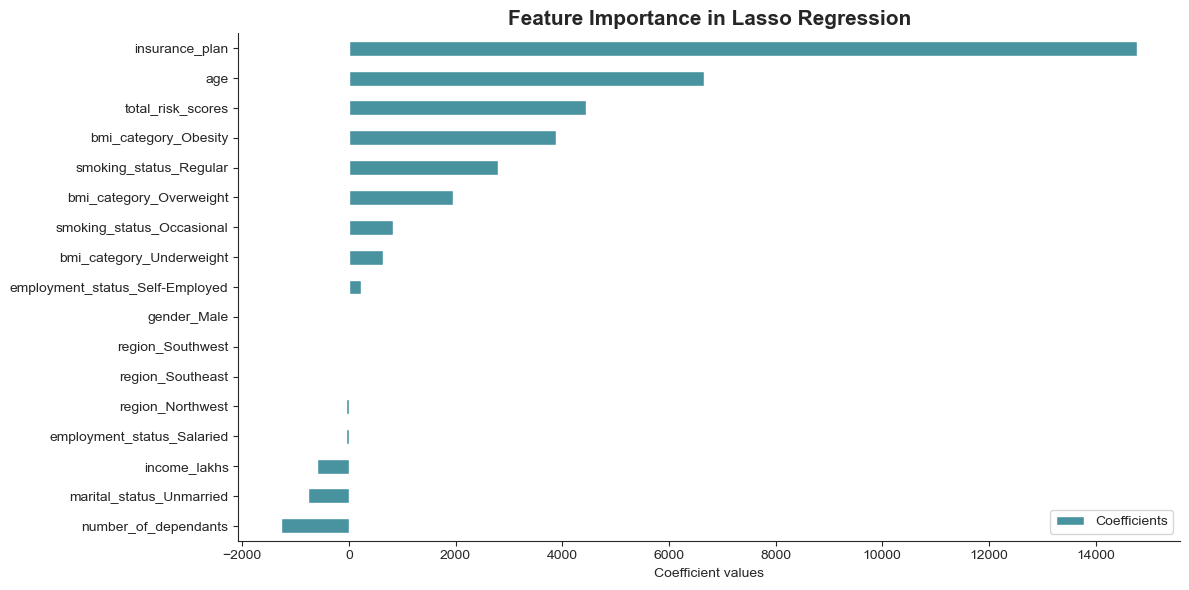

In [169]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in Lasso Regression", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

XGBoost : XGBRegressor Model

In [170]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [171]:
y_pred = model_xgb.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 1130922.420784021
RMSE: 1063.4483630078241
R2 Score: 0.9760981595627727


#### Hyparameter Tuning: XGBRegressor

1. Randomizedsearch CV

In [172]:
#use randomizedsearch cv
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

rscv = RandomizedSearchCV(estimator= model_xgb, param_distributions= param_grid, n_iter= 10, cv= kfold, scoring='r2')
rscv.fit(X_train, y_train)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=Non...
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [20, 40, 50]},
                   scoring='r2')

In [173]:
#print the best parameters and best scores
print(f"Best parameters: {rscv.best_params_}")
print(f"Best Score: {rscv.best_score_}")

#best model according to randomsearch cv
best_model = rscv.best_estimator_

Best parameters: {'n_estimators': 40, 'max_depth': 3, 'learning_rate': 0.2}
Best Score: 0.9781168714140408


In [174]:
feature_importance = best_model.feature_importances_
feature_importance_df = pd.DataFrame(feature_importance, columns= ['Coefficients'], index= X_test.columns)
feature_importance_df_sorted = feature_importance_df.sort_values(by='Coefficients')
feature_importance_df_sorted

,Coefficients
region_Southwest,0.000000
employment_status_Salaried,0.000000
region_Southeast,0.000000
region_Northwest,0.000000
gender_Male,0.000000
employment_status_Self-Employed,0.000000
number_of_dependants,0.000000
income_lakhs,0.000176
marital_status_Unmarried,0.001640
bmi_category_Underweight,0.005321


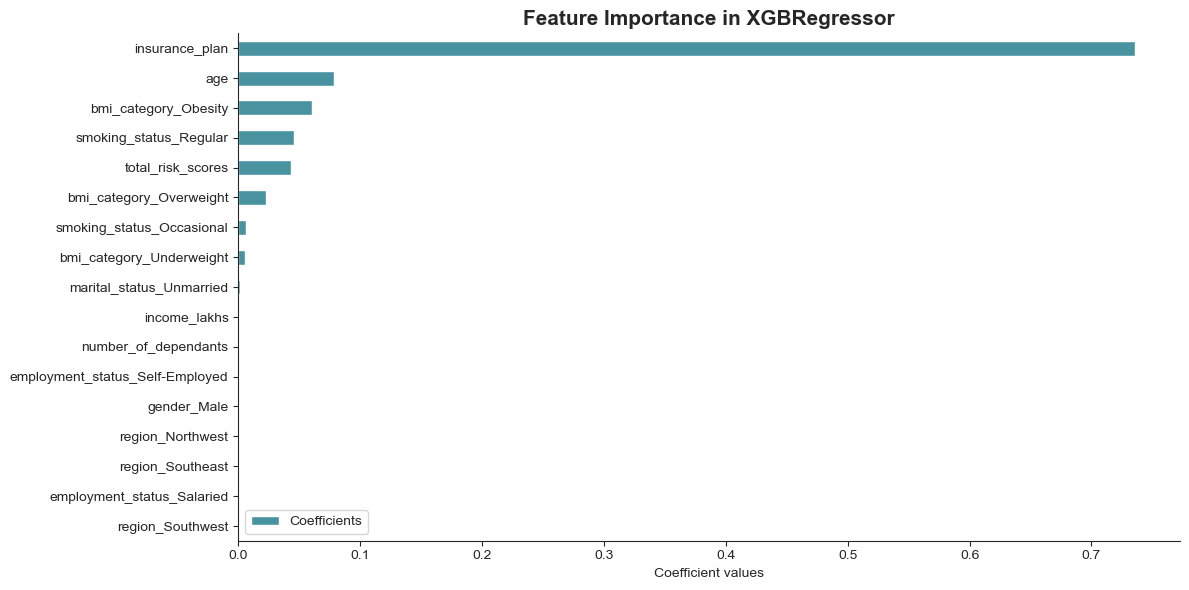

In [175]:
feature_importance_df_sorted.plot(kind='barh', color= "#48939F", figsize=(12,6))
plt.title("Feature Importance in XGBRegressor", fontsize = 15, fontweight = 'bold')
plt.xlabel("Coefficient values")
sns.despine()
plt.tight_layout()
plt.show()

##### R2 metric is not good enough to evaluate the model

#### ERROR ANALYSIS

In [176]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals * 100) / y_test

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})

results_df

,actual,predicted,diff,diff_pct
19713,26895,27065.779297,170.779297,0.634985
14750,22734,19679.740234,-3054.259766,-13.434766
19932,21198,22040.865234,842.865234,3.976155
29643,9100,9953.498047,853.498047,9.379099
17076,26434,26799.878906,365.878906,1.384122
...,...,...,...,...
3387,9291,9953.498047,662.498047,7.130535
7858,18261,14869.107422,-3391.892578,-18.574517
9744,12419,12279.932617,-139.067383,-1.119795
4849,29735,29750.640625,15.640625,0.052600


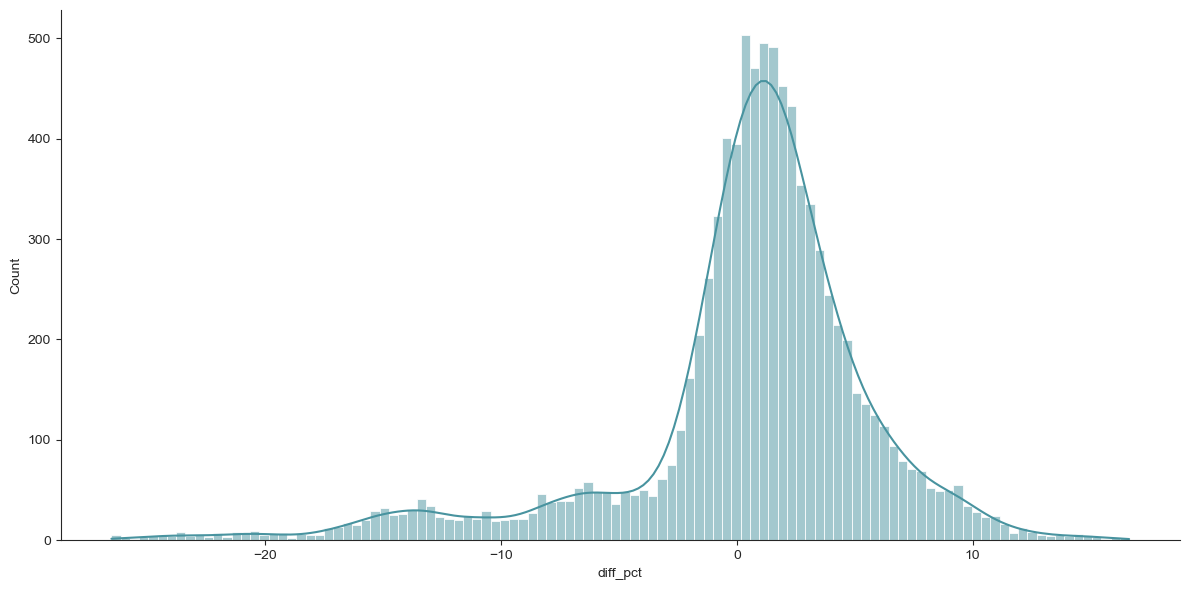

In [177]:
plt.figure(figsize=(12,6))
sns.histplot(results_df['diff_pct'], kde= True, color="#48939F")
sns.despine()
plt.tight_layout()
plt.show()

In [178]:
extreme_error_threshold = 10
extreme_result_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_result_df.shape

(718, 4)

In [179]:
results_df.shape

(8947, 4)

In [180]:
extreme_error_pct = (extreme_result_df.shape[0] * 100) / results_df.shape[0]
extreme_error_pct

8.025036325025148

We have few extreme errors (only 8.0%) which means this model looks good and no further investigation is required